# Project Milestone 5
* Data Preparation: DSC 540-T302 
* Mallory Young
* Student #21356619

## Loading Data into a Database
For my project, each Milestone was saved in a separate .ipynb jupyter notebook file. I used the syntax: _df.to_csv('film_revenue_data.csv', index=False)_ to save each of my cleansed datasets as a .csv file. 

I used the DB Browser for SQLite application to load my 3 csv files into a database titled "FilmDB". The 3 tables within the database created from my 3 milestone csv files are the following: 
* FilmNom - Contains the Wikipedia website data for Academy Award film nominations and wins.
* Holywd_gross - Contains the flat file data for the 1000 highest grossing movies.
* Film_revenue - Contains the TMDB API data for films with the highest revenue.

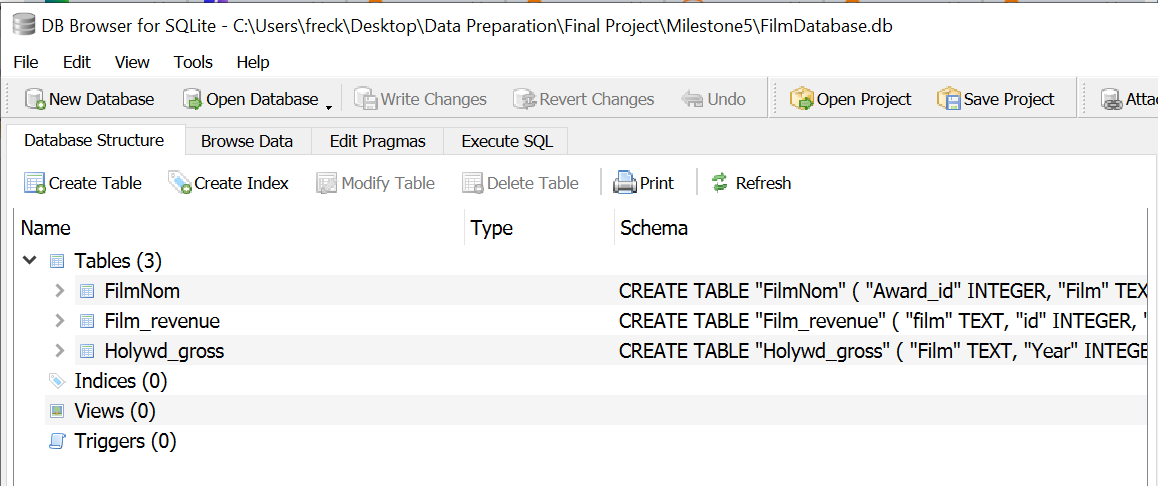

## Connecting to the Database
Connecting to the 'FilmDatabase' database and checking whether the connection has been successful. 

In [1]:
#importing the sqlite3 and os.path libraries from Python
import sqlite3
import os.path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
#Return a string representing the current working directory
os.getcwd()

'C:\\Users\\freck\\Desktop\\Data Preparation\\Final Project\\Milestone5'

In [3]:
#using the connect() function to connect to a database
conn = sqlite3.connect("C:\\Users\\freck\\Desktop\\Data Preparation\\Final Project\\Milestone5\\FilmDatabase.db")  

In [4]:
#creating a cursor object to execute SQL queries within the 'FilmDatabase' database
cursor = conn.cursor()

In [5]:
#a function that checks whether the connection has been successful
#the function uses a try/except to test the connection
def database_opened(conn):
    #try executes a SQL query to select all columns from the "FilmNom" table, but limiting the result to one row
    try:
        conn.execute("SELECT * FROM FilmNom LIMIT 1")
        #If the query is successful, 'True' is returned
        return True
    #except executes if an exception occurs during the SQL query
    except sqlite3.ProgrammingError as e:
        #a string is printed with the specific error message obtained from the exception e
        print("Connection unsuccessful {}".format(e))
        #if the query raises an exception, 'False' is returned
        return False

#calling the database_opened() function with the 'conn' argument, and the result is printed to the console.
print(database_opened(conn))

True


In [6]:
#selecting the first 10 rows of the "FilmNom" table to see verify the table data was successfully loaded into the database
rows = cursor.execute('SELECT * FROM FilmNom LIMIT 10')
#using a for loop to iterate through and print the rows in the FilmNom table 
for row in rows:
    print(row)

(1372, 'Oppenheimer', 2023, 7, 13, 'True')
(1366, 'Godzilla Minus One', 2023, 1, 1, 'False')
(1360, 'Poor Things', 2023, 4, 11, 'False')
(1361, 'The Zone of Interest', 2023, 2, 5, 'False')
(1362, 'American Fiction', 2023, 1, 5, 'False')
(1364, 'Barbie', 2023, 1, 8, 'False')
(1365, 'The Last Repair Shop', 2023, 1, 1, 'False')
(1363, 'Anatomy of a Fall', 2023, 1, 5, 'False')
(1367, 'The Holdovers', 2023, 1, 5, 'False')
(1368, '20 Days in Mariupol', 2023, 1, 1, 'False')


## Joining the 3 Tables into 1 Dataset

#### SQL Database Query #1: 
First, I will join all three tables using an implicit inner join. This join uses sql (without pandas) to complete the join. 

In [7]:
#writing an sql query to join the 3 tables
#retrieving all columns from the "FilmNom" table and combines the data with the "Holywd_gross" and "Film_revenue" tables 
#based on the "film" column in each table. 
sql = """
SELECT * FROM FilmNom \
JOIN Holywd_gross ON FilmNom.Film = Holywd_gross.film
JOIN Film_revenue ON FilmNom.Film - Film_revenue.film"""

#Executing the query
rows = cursor.execute(sql)
#printing the result set data
for row in rows:
    print(row)

(1311, '1917', 2019, 3, 10, 'False', '1917', 2019, '25-Dec-19', "['Action', 'Drama', 'War']", 'R', 'Universal Pictures', '1 hr 59 min', 'April 6th, 1917. As an infantry battalion assembles to wage war deep in enemy territory, two soldiers are assigned to race against time and deliver a message that will stop 1,600 men from walking straight into a deadly trap.', '$95,000,000.00', '$576,216.00', '$159,227,644.00', '$225,351,828.00', '$384,579,472.00', 'Avatar', 19995, 2009, '2009-12-15', 'English', '[28, 12, 14, 878]', 'United States of America, United Kingdom', '$2,923,706,026.00', '$-237,000,000.00', 75.959, 31102, 7.6, 'Released', 'Enter the world of Pandora.', 'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.', 162)
(1311, '1917', 2019, 3, 10, 'False', '1917', 2019, '25-Dec-19', "['Action', 'Drama', 'War']", 'R', 'Universal Pictures', '1 hr 59 min', 'April 6t

Next, I will complete this same join for all 3 tables. But, this time I will save the data in a Pandas DataFrame to be used when creating a visualization of the data. 

In [8]:
#writing an sql query to join the 3 tables
query = """
SELECT * FROM FilmNom 
JOIN Holywd_gross ON FilmNom.Film = Holywd_gross.film 
JOIN Film_revenue ON FilmNom.Film = Film_revenue.film
"""

#executing the query and retrieve the result into a pandas DataFrame
all3_df = pd.read_sql_query(query, conn)
#printing the 'all3_df' dataframe
all3_df

,Award_id,Film,Year,Awards,Nominations,Best Picture Winner,Film,Year,Release Date,Genre,...,production_countries,revenue (USD),budget (USD),popularity,vote_count,vote_average,release_status,tagline,plot,runtime (min)
0,1364,Barbie,2023,1,8,False,Barbie,2023,20-Nov-19,"['Adventure', 'Animation', 'Comedy', 'Drama', ...",...,"United Kingdom, United States of America","$1,445,638,421.00","$-145,000,000.00",190.582,8660,7.000,Released,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114
1,1349,Top Gun: Maverick,2022,1,6,False,Top Gun: Maverick,2022,1-Apr-15,"['Action', 'Crime', 'Thriller']",...,United States of America,"$1,488,732,821.00","$-170,000,000.00",124.634,8856,8.210,Released,Feel the need... The need for speed.,After more than thirty years of service as one...,131
2,1351,Avatar: The Way of Water,2022,1,4,False,Avatar: The Way of Water,2022,24-Apr-19,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",...,United States of America,"$2,320,250,281.00","$-460,000,000.00",173.696,11534,7.623,Released,Return to Pandora.,Set more than a decade after the events of the...,192
3,1290,Black Panther,2018,3,7,False,Black Panther,2018,22-Apr-15,"['Action', 'Adventure', 'Sci-Fi']",...,United States of America,"$1,349,926,083.00","$-200,000,000.00",101.685,21871,7.385,Released,Long live the king.,"King T'Challa returns home to the reclusive, t...",135
4,1157,Avatar,2009,3,9,False,Avatar,2009,16-Dec-09,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",...,"United States of America, United Kingdom","$2,923,706,026.00","$-237,000,000.00",75.959,31102,7.600,Released,Enter the world of Pandora.,"In the 22nd century, a paraplegic Marine is di...",162
5,984,Titanic,1997,11,14,True,Titanic,1997,19-Dec-97,"['Drama', 'Romance']",...,United States of America,"$2,264,162,353.00","$-200,000,000.00",181.279,24903,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194
6,937,The Lion King,1994,2,4,False,The Lion King,2019,11-Jul-19,"['Adventure', 'Drama', 'Family', 'Musical']",...,United States of America,"$1,663,000,000.00","$-260,000,000.00",103.600,9791,7.114,Released,The King has Returned.,"Simba idolizes his father, King Mufasa, and ta...",118
7,364,Titanic,1953,1,2,False,Titanic,1997,19-Dec-97,"['Drama', 'Romance']",...,United States of America,"$2,264,162,353.00","$-200,000,000.00",181.279,24903,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194


### Visualization 1: Heat Map
The following visualization is a heat map of the numerical columns for the joined 3 datasets. It shows data from  By exclusively focusing on numerical values, this heat map enables the identification of relationships (such as correlations and patterns) between various movie-related metrics such as ratings, budgets, and genre frequencies. Numerical data from all 3 datasets is represented in this visualization. 

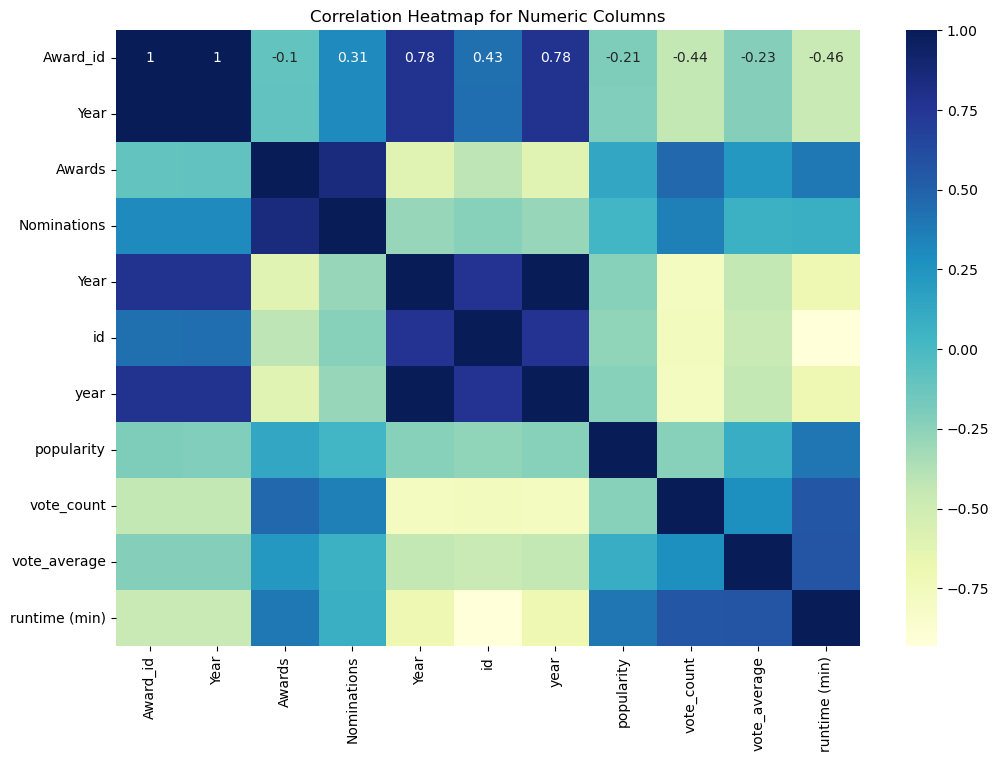

In [9]:
#selecting only the numeric columns from the dataframe and assign the selection to a variable
numeric_columns = all3_df.select_dtypes(include=[np.number])

#creating a correlation matrix for the numeric columns
correlation_matrix = numeric_columns.corr()

#setting the figure size for the heatmap
plt.figure(figsize=(12, 8))
#creating the heatmap with annotations and a specific color map that ranges from yellow (Yl) to green (Gn) to blue (Bu)
sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu")
#setting a title for the heatmap
plt.title('Correlation Heatmap for Numeric Columns')
#displaying the heatmap with the specified figure size, title, annotations, and color map ranges
plt.show()

## Joining 2 Tables into 1 Dataset
**The next two sets of visualizations will be created using different combinations of joins between 2 of the 3 datasets.** 

#### SQL Database Query #2: 
First, I will join the _Holywd_gross_ table with the _FilmNom_ table using an inner join. In this join I have specified the specific column names from each table that I wish to query. This join uses sql (without pandas) to complete the join.

In [10]:
#writing an sql query to join the 2 tables
#retrieving specified columns from the tables FilmNom and Holywd_gross by joining them based on the 'Film' column
sql2 = """
SELECT FilmNom.Award_id, FilmNom.Film, FilmNom.Year, FilmNom.Awards, Holywd_gross.rating, Holywd_gross.Distributor
FROM FilmNom
JOIN Holywd_gross
ON FilmNom.Film = Holywd_gross.Film"""

#executing the query
rows = cursor.execute(sql2)
#printing the result set data
for row in rows:
    print(row)

(1372, 'Oppenheimer', 2023, 7, 'PG', 'Universal Pictures')
(1364, 'Barbie', 2023, 1, 'PG', 'Warner Bros.')
(1349, 'Top Gun: Maverick', 2022, 1, 'PG-13', 'Paramount Pictures')
(1350, 'Black Panther: Wakanda Forever', 2022, 1, 'PG-13', 'Walt Disney Studios Motion Pictures')
(1351, 'Avatar: The Way of Water', 2022, 1, 'PG-13', '20th Century Studios')
(1333, 'Dune', 2021, 6, 'PG-13', 'Warner Bros.')
(1336, 'No Time to Die', 2021, 1, 'PG', 'Metro-Goldwyn-Mayer (MGM)')
(1341, 'Encanto', 2021, 1, 'R', 'Walt Disney Studios Motion Pictures')
(1345, 'Cruella', 2021, 1, 'PG-13', 'Walt Disney Studios Motion Pictures')
(1325, 'Tenet', 2020, 1, 'PG', 'Warner Bros.')
(1301, 'Parasite', 2019, 4, 'R', 'Neon')
(1302, 'Ford v Ferrari', 2019, 2, 'PG-13', 'Twentieth Century Fox')
(1305, 'Little Women', 2019, 1, 'PG', 'Sony Pictures Entertainment (SPE)')
(1308, 'Toy Story 4', 2019, 1, 'G', 'Walt Disney Studios Motion Pictures')
(1309, 'Joker', 2019, 2, 'R', 'Warner Bros.')
(1310, 'Once Upon a Time in Hollyw

Next, I will complete this same join for the 2 tables (_Holywd_gross_ and _FilmNom_). But, this time I will save the data in a Pandas DataFrame to be used when creating a visualization of the data. 

In [11]:
#writing an sql query to join the 2 tables
query2 = """
SELECT FilmNom.Award_id, FilmNom.Film, FilmNom.Year, FilmNom.Awards, Holywd_gross.rating, Holywd_gross.Distributor
FROM FilmNom
JOIN Holywd_gross
ON FilmNom.Film = Holywd_gross.Film"""

#executing the query and retrieve the result into a pandas DataFrame
gross_Nom_df = pd.read_sql_query(query2, conn)
#printing the 'gross_Nom_df' dataframe
gross_Nom_df

,Award_id,Film,Year,Awards,Rating,Distributor
0,1372,Oppenheimer,2023,7,PG,Universal Pictures
1,1364,Barbie,2023,1,PG,Warner Bros.
2,1349,Top Gun: Maverick,2022,1,PG-13,Paramount Pictures
3,1350,Black Panther: Wakanda Forever,2022,1,PG-13,Walt Disney Studios Motion Pictures
4,1351,Avatar: The Way of Water,2022,1,PG-13,20th Century Studios
...,...,...,...,...,...,...
178,121,Gone with the Wind,1939,8,R,Metro-Goldwyn-Mayer (MGM)
179,90,Snow White and the Seven Dwarfs,1937,0,PG-13,Walt Disney Studios Motion Pictures
180,103,A Star Is Born,1937,1,R,Warner Bros.
181,49,Little Women,1932,1,PG,Sony Pictures Entertainment (SPE)


### Visualization 2: Pie Chart
The following visualization is a pie chart displaying the distribution of film awards (from the _FilmNom_ table) among different film distributors (from the _Holywd_gross_ table). Each slice of the pie represents a film distributor, and the size of each slice corresponds to the percentage of awards received by that film distributor. 

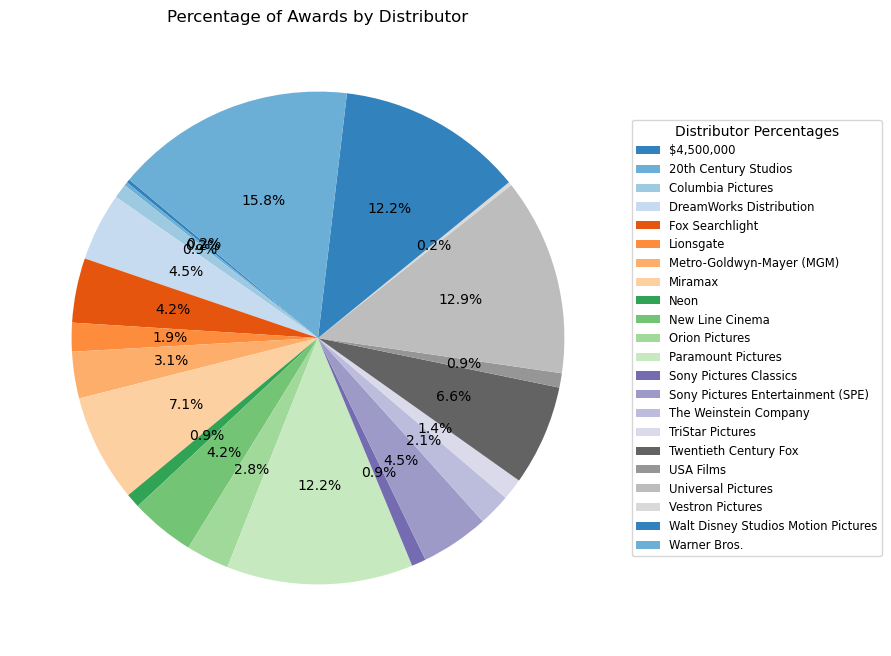

In [12]:
#calculating the percentage of awards for each distributor
#groupby groups the data by the 'Distributor' column, then applies the sum function to calculate the total awards for each distributor
#dividing the sum of awards for each distributor by the total sum of awards
#then, multiplying the proportions by 100 to convert them into percentages
percentage_awards = (gross_Nom_df.groupby('Distributor')['Awards'].sum() / gross_Nom_df['Awards'].sum()) * 100

#setting the size of the figure to 10 inches in width and 8 inches in height
plt.figure(figsize=(10, 8))
#creating a pie chart with the calculated percentage awards
#Setting labels to None, start angle to 140, colors to a predefined color map, and display percentage values with one decimal place
pie_chart = plt.pie(percentage_awards, labels=None, startangle=140, colors=plt.cm.tab20c.colors, autopct='%1.1f%%')
#adding a legend with percentages and position it off to the side
plt.legend(percentage_awards.index, loc='center left', bbox_to_anchor=(1, 0.5), title='Distributor Percentages', fontsize='small')
#setting a title for the pie chart
plt.title('Percentage of Awards by Distributor')
#display the plot with the specified figure size, pie chart, title, and legend
plt.show()

#### SQL Database Query #3: 
Next, I will join the _Film_revenue_ table with the _FilmNom_ table using an inner join. This join uses sql (without pandas) to complete the join.

In [13]:
#writing an sql query to join the 2 tables
#retrieving all columns from both the 'FilmNom' and 'Film_revenue' tables with FilmNom as the primary table
#performing an inner join between the 'FilmNom' and 'Film_revenue' tables based on the 'Year' column.
sql3 = """
SELECT FilmNom.*, Film_revenue.*
FROM FilmNom
INNER JOIN Film_revenue ON FilmNom.Year = Film_revenue.Year
"""
#executing the query
cursor.execute(sql3)

#This has query/join has a lot of rows, so I am only printing the first 5 rows. 
num_rows_to_fetch = 5  # Specify the number of rows to fetch
result = cursor.fetchmany(num_rows_to_fetch)

#printing the result set data
for row in result:
    print(row)

(1372, 'Oppenheimer', 2023, 7, 13, 'True', 'Barbie', 346698, 2023, '2023-07-19', 'English', '[35, 12]', 'United Kingdom, United States of America', '$1,445,638,421.00', '$-145,000,000.00', 190.582, 8660, 7.0, 'Released', "She's everything. He's just Ken.", 'Barbie and Ken are having the time of their lives in the colorful and seemingly perfect world of Barbie Land. However, when they get a chance to go to the real world, they soon discover the joys and perils of living among humans.', 114)
(1372, 'Oppenheimer', 2023, 7, 13, 'True', 'The Super Mario Bros. Movie', 502356, 2023, '2023-04-05', 'English', '[16, 10751, 12, 14, 35]', 'Japan, United States of America', '$1,362,000,000.00', '$-100,000,000.00', 243.674, 8727, 7.667, 'Released', 'Not all heroes wear capes. Some wear overalls.', 'While working underground to fix a water main, Brooklyn plumbers—and brothers—Mario and Luigi are transported down a mysterious pipe and wander into a magical new world. But when the brothers are separate

I will complete this same join for the 2 tables (_Film_revenue_ and _FilmNom_). But, this time I will save the data in a Pandas DataFrame to be used when creating a visualization of the data. 

In [14]:
#writing an sql query to join the 2 tables
query3 = """
SELECT * FROM FilmNom
INNER JOIN Film_revenue ON FilmNom.year = Film_revenue.year"""

#executing the query and retrieve the result into a pandas DataFrame
revenue_Nom_df = pd.read_sql_query(query3, conn)
#printing the 'gross_Nom_df' dataframe
revenue_Nom_df

,Award_id,Film,Year,Awards,Nominations,Best Picture Winner,film,id,year,release_date,...,production_countries,revenue (USD),budget (USD),popularity,vote_count,vote_average,release_status,tagline,plot,runtime (min)
0,1372,Oppenheimer,2023,7,13,True,Barbie,346698,2023,2023-07-19,...,"United Kingdom, United States of America","$1,445,638,421.00","$-145,000,000.00",190.582,8660,7.000,Released,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114
1,1372,Oppenheimer,2023,7,13,True,The Super Mario Bros. Movie,502356,2023,2023-04-05,...,"Japan, United States of America","$1,362,000,000.00","$-100,000,000.00",243.674,8727,7.667,Released,Not all heroes wear capes. Some wear overalls.,"While working underground to fix a water main,...",93
2,1366,Godzilla Minus One,2023,1,1,False,Barbie,346698,2023,2023-07-19,...,"United Kingdom, United States of America","$1,445,638,421.00","$-145,000,000.00",190.582,8660,7.000,Released,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114
3,1366,Godzilla Minus One,2023,1,1,False,The Super Mario Bros. Movie,502356,2023,2023-04-05,...,"Japan, United States of America","$1,362,000,000.00","$-100,000,000.00",243.674,8727,7.667,Released,Not all heroes wear capes. Some wear overalls.,"While working underground to fix a water main,...",93
4,1360,Poor Things,2023,4,11,False,Barbie,346698,2023,2023-07-19,...,"United Kingdom, United States of America","$1,445,638,421.00","$-145,000,000.00",190.582,8660,7.000,Released,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,990,Visas and Virtue,1997,1,1,False,Titanic,597,1997,1997-11-18,...,United States of America,"$2,264,162,353.00","$-200,000,000.00",181.279,24903,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194
276,992,Geri's Game,1997,1,1,False,Titanic,597,1997,1997-11-18,...,United States of America,"$2,264,162,353.00","$-200,000,000.00",181.279,24903,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194
277,993,The Long Way Home,1997,1,1,False,Titanic,597,1997,1997-11-18,...,United States of America,"$2,264,162,353.00","$-200,000,000.00",181.279,24903,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194
278,991,Character (Karakter),1997,1,1,False,Titanic,597,1997,1997-11-18,...,United States of America,"$2,264,162,353.00","$-200,000,000.00",181.279,24903,7.906,Released,Nothing on Earth could come between them.,101-year-old Rose DeWitt Bukater tells the sto...,194


### Visualization 3: Bar Chart
The following visualization is a bar chart displaying how many Academy Awards a film won (from the _FilmNom_ table) compared to the its popularity rating (from the _Film_revenue_ table). This visualization is useful in showing that maybe not all of the award winning films were necessarily the most popularly rated films. 

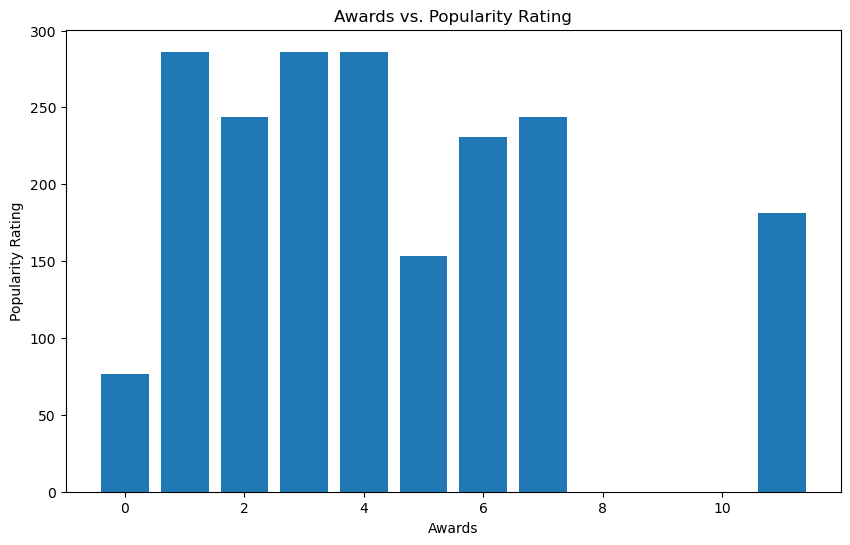

In [15]:
#setting the size of the figure to 10 inches in width and 8 inches in height
plt.figure(figsize=(10, 6))
#creating a bar chart using the data in the 'Awards' and 'Title' columns
plt.bar(revenue_Nom_df['Awards'], revenue_Nom_df['popularity'])
#setting a title for the bar chart
plt.title('Awards vs. Popularity Rating')
#setting the labels for the x and y axes
plt.xlabel('Awards')
plt.ylabel('Popularity Rating')
#display the plot with the specified figure size, bar chart, title, and axis labels
plt.show()

## Querying Data from 1 Dataset
**The next two sets of visualizations will be created by querying from a single table in the database.** 

#### SQL Database Query #4: 

This is a sql query of the _Film_revenue_ data table from the database. (Pandas is not used for this query)

In [16]:
#writing an sql query to pull the FilmNom table data
#Using a SELECT * to select all of the table data 
sql4 = """SELECT * FROM Film_revenue"""

#executing the query
rows = cursor.execute(sql4)
#printing the result set data
for row in rows:
    print(row)

('Avatar', 19995, 2009, '2009-12-15', 'English', '[28, 12, 14, 878]', 'United States of America, United Kingdom', '$2,923,706,026.00', '$-237,000,000.00', 75.959, 31102, 7.6, 'Released', 'Enter the world of Pandora.', 'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.', 162)
('Avengers: Endgame', 299534, 2019, '2019-04-24', 'English', '[12, 878, 28]', 'United States of America', '$2,799,439,100.00', '$-356,000,000.00', 163.58, 25149, 8.254, 'Released', 'Avenge the fallen.', "After the devastating events of Avengers: Infinity War, the universe is in ruins due to the efforts of the Mad Titan, Thanos. With the help of remaining allies, the Avengers must assemble once more in order to undo Thanos' actions and restore order to the universe once and for all, no matter what consequences may be in store.", 181)
('Avatar: The Way of Water', 76600, 2022, '2022-12-14', 'En

This is the same query of the _Film_revenue_ table but, this time I will save the data in a Pandas DataFrame to be used when creating a visualization of the data. 

In [33]:
#writing an sql query to join the 2 tables
query4 = """SELECT * FROM Holywd_gross GROUP BY Year"""

#executing the query and retrieve the result into a pandas DataFrame
Film_revenue_df = pd.read_sql_query(query4, conn)
#printing the 'Film_revenue_df' dataframe
Film_revenue_df

,Film,Year,Release Date,Genre,Rating,Distributor,Running Time,Movie Info,Budget,Domestic Opening,Domestic Sales,International Sales (USD),World Wide Sales (USD)
0,Snow White and the Seven Dwarfs,1937,18-May-01,"['Drama', 'Musical', 'Romance']",PG-13,Walt Disney Studios Motion Pictures,2 hr 7 min,Exiled into the dangerous forest by her wicked...,None,"$1,499,000.00","$184,925,486.00","$184,925,486.00","$184,928,542.00"
1,Gone with the Wind,1939,30-May-12,"['Adventure', 'Mystery', 'Sci-Fi']",R,Metro-Goldwyn-Mayer (MGM),2 hr 4 min,A sheltered and manipulative Southern belle an...,"$130,000,000.00",None,"$200,882,193.00","$201,500,000.00","$402,382,193.00"
2,Bambi,1942,4-Oct-17,"['Action', 'Drama', 'Mystery', 'Sci-Fi', 'Thri...",R,RKO Radio Pictures,2 hr 44 min,The story of a young deer growing up in the fo...,"$150,000,000.00",None,"$102,247,150.00","$165,200,000.00","$267,447,150.00"
3,One Hundred and One Dalmatians,1961,5-Aug-94,"['Action', 'Crime', 'Drama', 'Thriller']",PG-13,Walt Disney Studios Motion Pictures,2 hr 21 min,When a litter of Dalmatian puppies are abducte...,"$62,000,000.00",None,"$144,880,014.00","$71,000,000.00","$215,880,014.00"
4,The Jungle Book (Remake),1967,5-Dec-06,"['Comedy', 'Romance']",PG-13,Walt Disney Studios Motion Pictures,2 hr 16 min,Bagheera the Panther and Baloo the Bear have a...,"$85,000,000.00",None,"$141,843,612.00","$64,000,000.00","$205,843,612.00"
5,The Godfather,1972,15-Mar-72,"['Crime', 'Drama']",None,Paramount Pictures,2 hr 55 min,"Don Vito Corleone, head of a mafia family, dec...","$6,000,000.00","$302,393.00","$136,381,073.00","$113,960,743.00","$250,341,816.00"
6,The Exorcist,1973,19-Dec-12,"['Drama', 'Musical', 'Romance']",PG-13,Warner Bros.,2 hr 38 min,When a young girl is possessed by a mysterious...,None,"$11,000,000.00","$233,005,644.00","$136,017,945.00","$441,306,145.00"
7,Jaws,1975,20-Jun-75,"['Adventure', 'Mystery', 'Thriller']",None,Universal Pictures,2 hr 4 min,When a killer shark unleashes chaos on a beach...,"$7,000,000.00","$7,061,513.00","$265,859,065.00","$210,653,000.00","$476,512,065.00"
8,Star Wars: Episode IV - A New Hope,1977,25-May-77,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",PG,Twentieth Century Fox,2 hr 1 min,Luke Skywalker joins forces with a Jedi Knight...,"$11,000,000.00","$1,554,475.00","$460,998,507.00","$195,751,992.00","$775,398,007.00"
9,Grease,1978,16-Jun-78,"['Comedy', 'Musical', 'Romance']",PG,Paramount Pictures,1 hr 50 min,Good girl Sandy Olsson and greaser Danny Zuko ...,"$6,000,000.00","$8,941,717.00","$190,071,103.00","$206,200,000.00","$396,271,103.00"


In [35]:
# Assuming Film_revenue_df is the DataFrame containing the data
# Replace 'runtime (min)' and 'Year' with the actual column names in your DataFrame

# Create a line plot to visualize the change in runtime over the years
plt.figure(figsize=(10, 6))
plt.plot(Film_revenue_df['Year'], Film_revenue_df['Runtime'], marker='o', linestyle='-')
plt.title('Film Runtime Over the Years')
plt.xlabel('Year')
plt.ylabel('Runtime (min)')
plt.grid(True)
plt.show()

KeyError: 'Runtime'

<Figure size 1000x600 with 0 Axes>

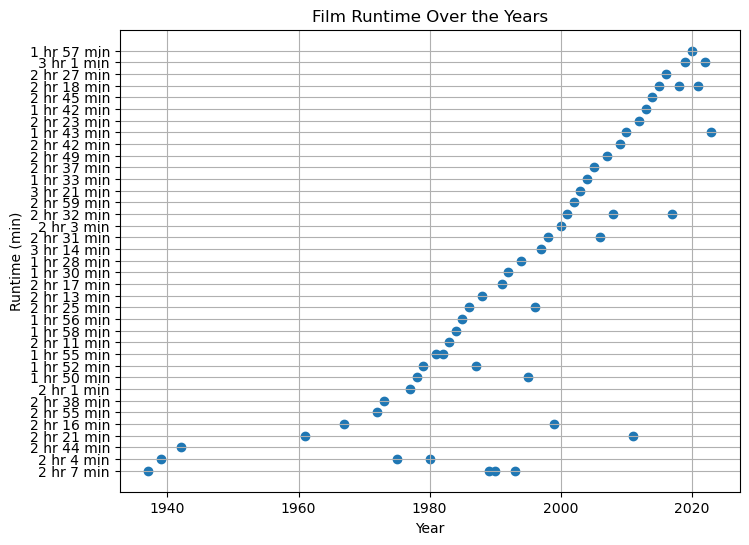

In [36]:
# Create a scatter plot to visualize the relationship between film runtime and years
plt.figure(figsize=(8, 6))
plt.scatter(Film_revenue_df['Year'], Film_revenue_df['Running Time'])
plt.title('Film Runtime Over the Years')
plt.xlabel('Year')
plt.ylabel('Runtime (min)')
plt.grid(True)
plt.show()

#### SQL Database Query #5: 

This is a sql query of the _FilmNom_ data table from the database. Selecting all of the data, but using a WHERE clause to specify only data from years greater than or equal to 1960. (Pandas is not used for this query)

In [ ]:
#writing an sql query to pull the FilmNom table data
#using a SELECT * to select all of the table data 
#using a WHERE clause to filter the results to years greater than or equal to 1960
sql5 = """SELECT * FROM FilmNom WHERE Year >= 1960"""

#executing the query
rows = cursor.execute(sql5)
#printing the result set data
for row in rows:
    print(row)

This is the same query of the _Film_Nom_ table but, this time I will save the data in a Pandas DataFrame to be used when creating a visualization of the data. 

In [ ]:
#writing an sql query to join the 2 tables
query5 = """SELECT * FROM FilmNom WHERE Year >= 1960"""

#executing the query and retrieve the result into a pandas DataFrame
FilmNom_df = pd.read_sql_query(query5, conn)
#printing the 'Film_Nom_df' dataframe
FilmNom_df

### Visualization 5: Box Plot
The box plot below provides a visual representation of the distribution of the number of nominations received by films, categorized based on whether they won the "Best Picture" award based on data from the _FilmNom_ dataset. This data shows only data from years greater than or equal to 1960. The box plot enables a visual comparison of the distribution of nominations for "Best Picture Winners" and non-winners. It provides insights into the differences in the spread, central tendency, and potential outliers between the two categories, aiding in the assessment of the relationship between the number of nominations and the "Best Picture Winner" status.

In [ ]:
#setting the figure size for the box plot
plt.figure(figsize=(8, 6))
#creating the boxplot with seaborn
#Specifying the data frame, and columns to plot on the x and y axes. 
sns.boxplot(x='Best Picture Winner', y='Nominations', data=FilmNom_df)
#setting a title for the boxplot
plt.title('Comparison of Nominations for Best Picture Winners')
##setting the labels for the x and y axes
plt.xlabel('Best Picture Winner')
plt.ylabel('Nominations')
##display the plot with the specified figure size, boxplot, title, and axis labels
plt.show()